In [1]:
import sys
sys.path.append('..')

import numpy as np
from sklearn.datasets import make_blobs
from matplotlib import pyplot as plt

In [2]:
TEACHER_DIR = '../models/teacher'
DIM    = 8192
CSCALE = 0.5

centers = np.load(f'{TEACHER_DIR}/makeblobs_{DIM}d_cscale{CSCALE}_centers_seed42.npy')            # (2, DIM)
w_star  = np.load(f'{TEACHER_DIR}/makeblobs_{DIM}d_cscale{CSCALE}_wstar_seed42.npy')              # (DIM,)
w_hat   = np.load(f'{TEACHER_DIR}/makeblobs_{DIM}d_cscale{CSCALE}_wnoised_alpha1.0_nseed0.npy')   # (DIM,)

cos_theta = float(np.dot(w_star, w_hat))
theta_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
print(f'cos θ = {cos_theta:.4f},  θ = {theta_deg:.1f}°')

cos θ = 0.7042,  θ = 45.2°


In [12]:
# Match params in configs/makeblobs/data/makeblobs-template.yaml
# random_state falls back to config seed=1
X, y = make_blobs(
    n_samples=100,
    n_features=DIM,
    centers=centers,
    cluster_std=1.0,
    random_state=2,
)
print('made them blobs')
print('old dtype', X.dtype)
X = X.astype(np.float32)
print(f'X shape: {X.shape}, classes: {np.unique(y)}')

made them blobs
old dtype float64
X shape: (100, 8192), classes: [0 1]


In [13]:
e1 = w_star / np.linalg.norm(w_star)
e2_raw = w_hat - np.dot(w_hat, e1) * e1
e2 = e2_raw / np.linalg.norm(e2_raw)

X_proj = X @ np.stack([e1, e2], axis=1)   # (N, 2)

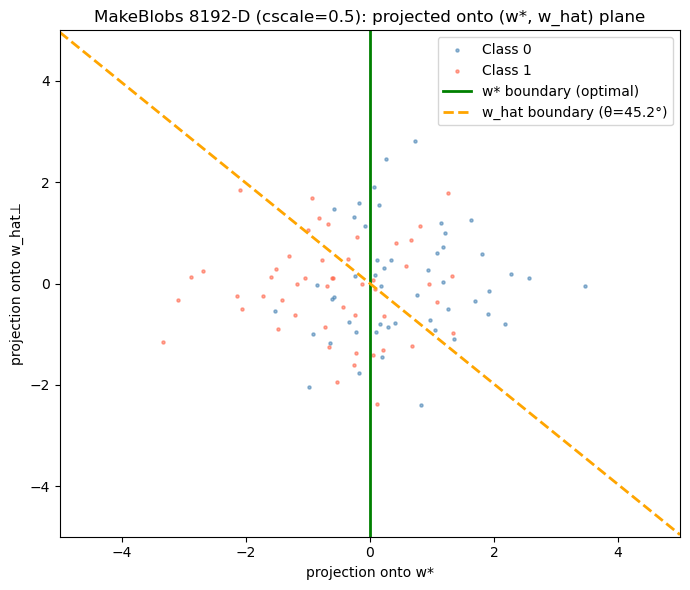

In [16]:
fig, ax = plt.subplots(figsize=(7, 6))

for cls, label, color in [(0, 'Class 0', 'steelblue'), (1, 'Class 1', 'tomato')]:
    mask = y == cls
    ax.scatter(X_proj[mask, 0], X_proj[mask, 1],
               alpha=0.55, s=5, color=color, label=label)

t = np.linspace(-5, 5, 300)

# w* boundary: perpendicular to e1=(1,0) → vertical line x1=0
ax.axvline(0, color='green', lw=2, label='w* boundary (optimal)')

# w_hat boundary: perpendicular to (cos θ, sin θ) → slope = -cos θ / sin θ
sin_theta = np.sqrt(1 - cos_theta**2)
slope = -cos_theta / sin_theta if sin_theta > 1e-8 else np.inf
if np.isfinite(slope):
    ax.plot(t, slope * t, color='orange', lw=2, ls='--',
            label=f'w_hat boundary (θ={theta_deg:.1f}°)')

ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_xlabel('projection onto w*')
ax.set_ylabel('projection onto w_hat⊥')
ax.set_title(f'MakeBlobs {DIM}-D (cscale={CSCALE}): projected onto (w*, w_hat) plane')
ax.legend()
plt.tight_layout()
plt.show()

In [15]:
# Sign of projection onto w gives predicted class (positive → class 0, negative → class 1)
pred_wstar = (X @ w_star < 0).astype(int)
pred_what  = (X @ w_hat  < 0).astype(int)

acc_wstar = (pred_wstar == y).mean()
acc_what  = (pred_what  == y).mean()

print(f'w*    accuracy: {acc_wstar:.4f}')
print(f'w_hat accuracy: {acc_what:.4f}')
print(f'accuracy gap:   {acc_wstar - acc_what:.4f}')

w*    accuracy: 0.6900
w_hat accuracy: 0.6700
accuracy gap:   0.0200
